<a href="https://colab.research.google.com/github/lamaljalal/MachineLearning/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
Index: 1290 entries, 0 to 3278
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1290 non-null   object        
 1   Country        1290 non-null   object        
 2   Product        1290 non-null   object        
 3   Date           1290 non-null   datetime64[ns]
 4   Amount         1290 non-null   float64       
 5   Boxes Shipped  1290 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 70.5+ KB
7669205.19
Product
Smooth Sliky Salty      542744.06
White Choc              528785.60
Baker's Choco Chips     471928.81
Peanut Butter Cubes     465550.79
Spicy Special Slims     447567.15
85% Dark Bars           442633.22
50% Dark Bites          426102.73
Organic Choco Syrup     387275.83
Milk Bars               382409.56
Drinking Coco           355393.04
Eclairs                 353308.87
Choco Coated Alm

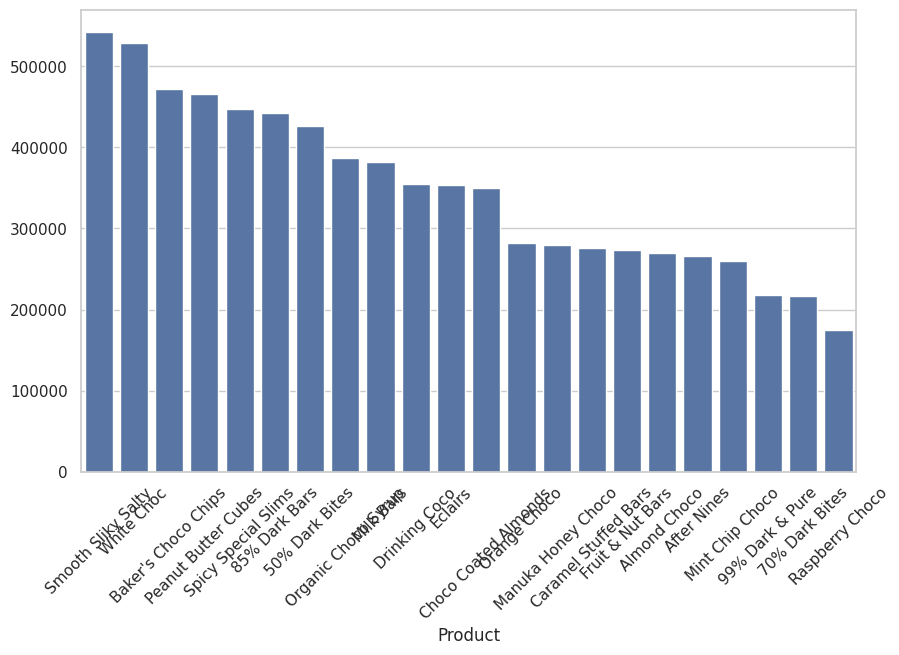

Country
Canada         1431493.99
India          1374994.12
Australia      1373609.42
UK             1264982.30
New Zealand    1155763.30
USA            1068362.06
Name: Amount, dtype: float64


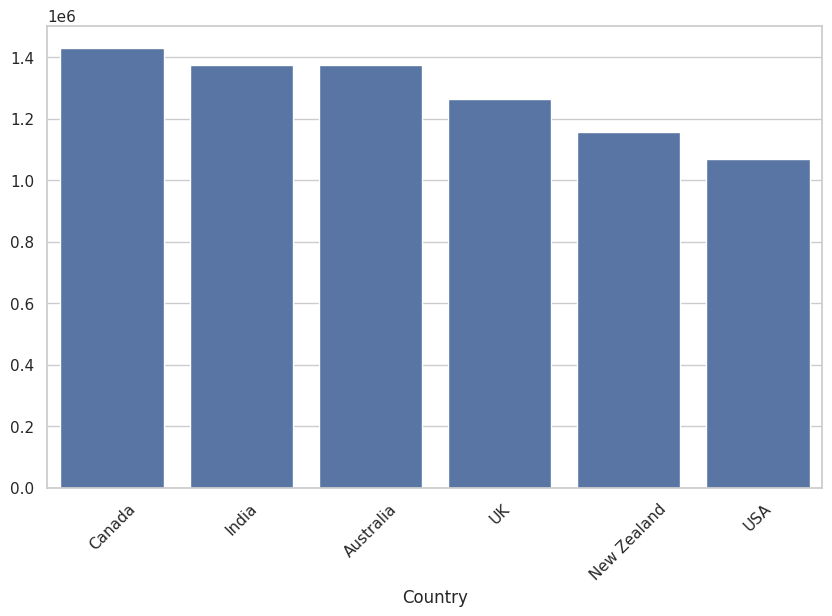

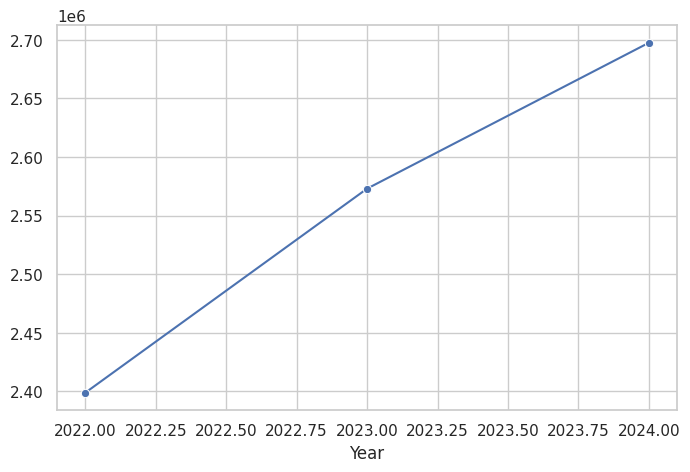

Smooth Sliky Salty
Canada


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("Chocolate_Sales.csv")
df.columns = df.columns.str.strip()

df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df = df.dropna(subset=["Amount"])

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])

df.info()
df.describe()

total_sales = df["Amount"].sum()
print(total_sales)

sales_by_product = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)
print(sales_by_product)

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_product.index, y=sales_by_product.values)
plt.xticks(rotation=45)
plt.show()

sales_by_country = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)
print(sales_by_country)

plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_country.index, y=sales_by_country.values)
plt.xticks(rotation=45)
plt.show()

df["Year"] = df["Date"].dt.year
sales_by_year = df.groupby("Year")["Amount"].sum()

plt.figure(figsize=(8,5))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values, marker="o")
plt.show()

print(sales_by_product.idxmax())
print(sales_by_country.idxmax())




## Key Insights
- The product **Smooth Silky Salty** generates the highest total sales amount.
- **Canada** is the top-performing country in terms of total sales revenue.
- Sales show an overall increasing trend over the years, indicating business growth over time.
- Dark chocolate products generally perform well compared to other categories.
